In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [10]:

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [11]:

# ========== ENHANCED TRANSFORM WITH AUGMENTATION ==========
transform_train = transforms.Compose([
    transforms.RandomRotation(10),  # Small rotations
    transforms.RandomAffine(0, translate=(0.1, 0.1)),  # Small translations
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


In [12]:

# Load data
train_data = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transform_train
)

test_data = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transform_test
)


In [13]:

# Split train into train/validation
train_size = int(0.9 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

# ========== ENHANCED MODEL WITH BATCH NORM ==========
class EnhancedCNN(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(EnhancedCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.conv2_drop = nn.Dropout2d(dropout_rate)
        
        # Calculate size after convolutions and pooling
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        # First block
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)
        
        # Second block
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)
        
        # Third block
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.conv2_drop(x)
        x = F.max_pool2d(x, 2)
        
        # Flatten
        x = x.view(-1, 128 * 3 * 3)
        
        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return F.log_softmax(x, dim=1)


In [14]:

# ========== CREATE DATA LOADERS ==========
batch_size = 128

loaders = {
    'train': DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2),
    'val': DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2),
    'test': DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)
}


In [15]:

# ========== MODEL INITIALIZATION ==========
model = EnhancedCNN(dropout_rate=0.3).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # Added weight decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
loss_fn = nn.CrossEntropyLoss()


In [16]:

# ========== TRAINING WITH EARLY STOPPING ==========
def train_epoch(epoch):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(loaders['train']):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += data.size(0)
        
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_subset)} '
                  f'({100. * batch_idx / len(loaders["train"]):.0f}%)]\tLoss: {loss.item():.6f}')
    
    avg_loss = train_loss / total
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def validate():
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in loaders['val']:
            data, target = data.to(device), target.to(device)
            output = model(data)
            val_loss += loss_fn(output, target).item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += data.size(0)
    
    avg_loss = val_loss / total
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def test():
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += loss_fn(output, target).item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += data.size(0)
            
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    avg_loss = test_loss / total
    accuracy = 100. * correct / total
    
    print(f'\nTest set: Average loss: {avg_loss:.4f}, '
          f'Accuracy: {correct}/{total} ({accuracy:.2f}%)\n')
    
    return avg_loss, accuracy, all_preds, all_targets


In [18]:

# ========== TRAINING LOOP WITH EARLY STOPPING ==========
def train_model(epochs=20, patience=5):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(1, epochs + 1):
        # Train
        train_loss, train_acc = train_epoch(epoch)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Validate
        val_loss, val_acc = validate()
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        print(f'\nEpoch {epoch}:')
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            torch.save(model.state_dict(), 'best_mnist_model.pth')
            print(f'Model saved!')
        else:
            patience_counter += 1
            print(f'No improvement for {patience_counter} epoch(s)')
            
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch}')
                break
    
 # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    return train_losses, val_losses, train_accs, val_accs


Starting training...
Train Epoch: 1 [0/54000 (0%)]	Loss: 2.333422
Train Epoch: 1 [12800/54000 (24%)]	Loss: 0.518509
Train Epoch: 1 [25600/54000 (47%)]	Loss: 0.167801
Train Epoch: 1 [38400/54000 (71%)]	Loss: 0.127827
Train Epoch: 1 [51200/54000 (95%)]	Loss: 0.082229

Epoch 1:
Train Loss: 0.3346, Train Acc: 89.27%
Val Loss: 0.0984, Val Acc: 96.63%
Model saved!
Train Epoch: 2 [0/54000 (0%)]	Loss: 0.215139
Train Epoch: 2 [12800/54000 (24%)]	Loss: 0.092382
Train Epoch: 2 [25600/54000 (47%)]	Loss: 0.119627
Train Epoch: 2 [38400/54000 (71%)]	Loss: 0.055078
Train Epoch: 2 [51200/54000 (95%)]	Loss: 0.116135

Epoch 2:
Train Loss: 0.1183, Train Acc: 96.45%
Val Loss: 0.0560, Val Acc: 98.38%
Model saved!
Train Epoch: 3 [0/54000 (0%)]	Loss: 0.085525
Train Epoch: 3 [12800/54000 (24%)]	Loss: 0.029023
Train Epoch: 3 [25600/54000 (47%)]	Loss: 0.106140
Train Epoch: 3 [38400/54000 (71%)]	Loss: 0.132170
Train Epoch: 3 [51200/54000 (95%)]	Loss: 0.089228

Epoch 3:
Train Loss: 0.0943, Train Acc: 97.19%
Val Lo

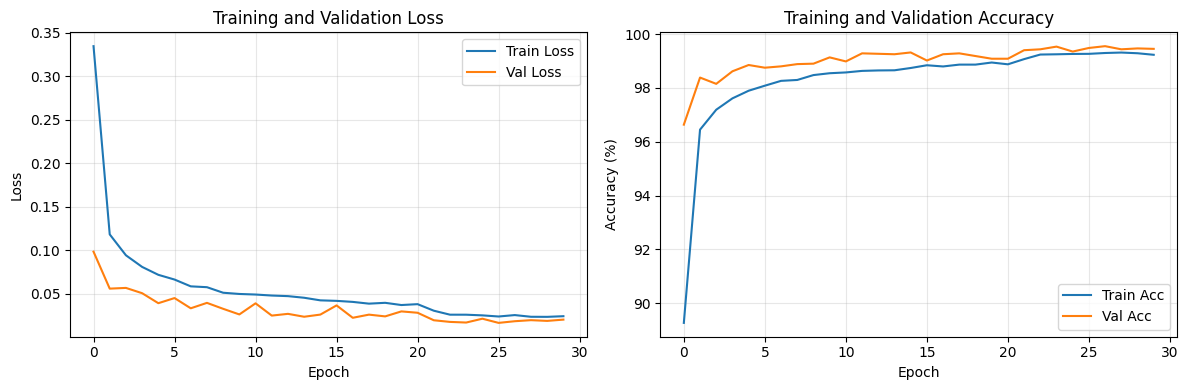

In [19]:
# ========== TRAIN THE MODEL ==========
print("Starting training...")
train_losses, val_losses, train_accs, val_accs = train_model(epochs=30)


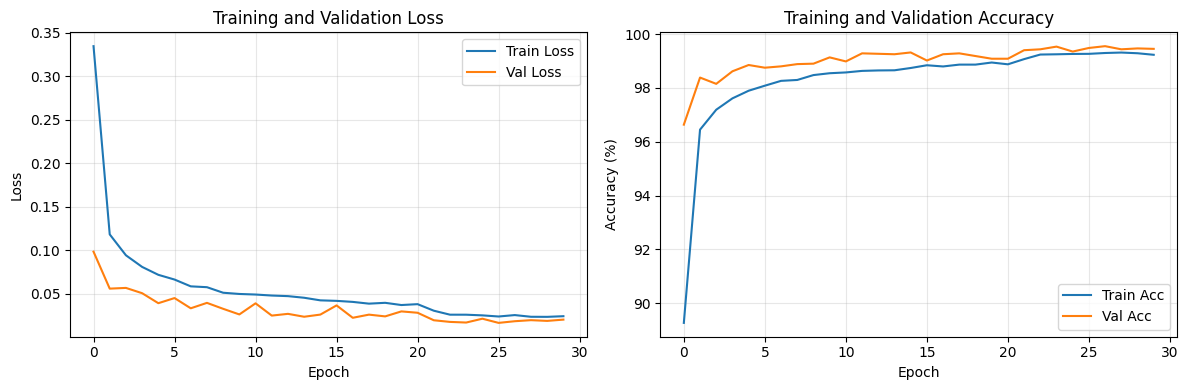

In [20]:

# ========== PLOT TRAINING HISTORY ==========
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(val_accs, label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:


# ========== FINAL TEST ==========
print("\nFinal evaluation on test set:")
test_loss, test_acc, all_preds, all_targets = test()

# ========== CONFUSION MATRIX ==========
print("\nConfusion Matrix:")
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Accuracy: {test_acc:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ========== CLASSIFICATION REPORT ==========
print("\nClassification Report:")
print(classification_report(all_targets, all_preds, digits=4))

# ========== VISUALIZE PREDICTIONS ==========
def visualize_predictions(num_images=25):
    model.eval()
    plt.figure(figsize=(10, 10))
    
    indices = np.random.choice(len(test_data), num_images, replace=False)
    
    for i, idx in enumerate(indices):
        data, target = test_data[idx]
        data = data.unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(data)
            pred = output.argmax(dim=1).item()
            prob = torch.exp(output).max().item()
        
        image = data.squeeze().cpu().numpy()
        
        plt.subplot(5, 5, i + 1)
        plt.imshow(image, cmap='gray')
        
        color = 'green' if pred == target else 'red'
        plt.title(f'T:{target} P:{pred}\n({prob:.2f})', color=color)
        plt.axis('off')
    
    plt.suptitle('MNIST Predictions (Green=Correct, Red=Wrong)\nT=True, P=Predicted, (Probability)')
    plt.tight_layout()
    plt.show()

visualize_predictions()



Found 49 errors (0.49% of test set)


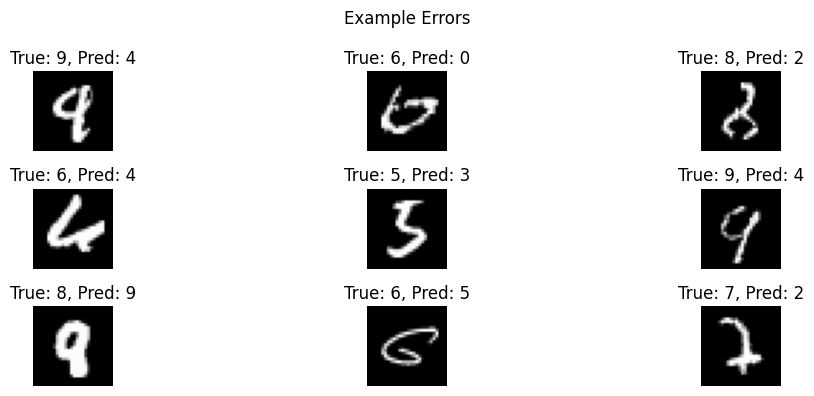


Most common error types (True -> Predicted):
9 -> 4: 7 times
5 -> 3: 4 times
7 -> 2: 4 times
6 -> 1: 4 times
6 -> 0: 3 times

Final Model Architecture:
EnhancedCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_drop): Dropout2d(p=0.3, inplace=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Total parameters: 422,474


In [21]:
   
# ========== ANALYZE ERRORS ==========
def analyze_errors():
    model.eval()
    errors = []
    
    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            
            # Find errors
            mask = (pred != target)
            if mask.any():
                error_indices = torch.where(mask)[0]
                for idx in error_indices:
                    errors.append({
                        'image': data[idx].cpu(),
                        'true': target[idx].item(),
                        'pred': pred[idx].item(),
                        'probs': torch.exp(output[idx]).cpu().numpy()
                    })
    
    if errors:
        print(f"\nFound {len(errors)} errors ({100 * len(errors) / len(test_data):.2f}% of test set)")
        
        # Show some error examples
        num_show = min(9, len(errors))
        plt.figure(figsize=(12, 4))
        
        for i in range(num_show):
            error = errors[i]
            plt.subplot(3, 3, i + 1)
            plt.imshow(error['image'].squeeze(), cmap='gray')
            plt.title(f"True: {error['true']}, Pred: {error['pred']}")
            plt.axis('off')
        
        plt.suptitle('Example Errors')
        plt.tight_layout()
        plt.show()
        
        # Analyze most common error types
        error_pairs = [(e['true'], e['pred']) for e in errors]
        from collections import Counter
        common_errors = Counter(error_pairs).most_common(5)
        
        print("\nMost common error types (True -> Predicted):")
        for (true, pred), count in common_errors:
            print(f"{true} -> {pred}: {count} times")
    else:
        print("\nNo errors found!")

analyze_errors()

print(f"\nFinal Model Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")